<a href="https://colab.research.google.com/github/yrhutu21/Data_Science_MIniProjects/blob/main/Task3_Geospatial_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install folium

In [ ]:
import pandas as pd
import folium #for interactive maps

In [ ]:
df = pd.read_csv('/content/Dataset .csv')
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [22]:
#Creation of map centered at average  Location

# Create map
map_center = [df['Latitude'].mean(), df['Longitude'].mean()]
restaurant_map = folium.Map(location=map_center, zoom_start=5)

restaurant_map.save("restaurant_map.html")
from google.colab import files
files.download("restaurant_map.html")


restaurant_map


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Add Restaurant Markers

In [23]:
for index, row in df.head(100).iterrows():  # limit to 100 points
    folium.Marker(
        location=[row['Latitude'], row['Longitude']],
        popup=row['Restaurant Name']
    ).add_to(restaurant_map)

restaurant_map.save("restaurant_map_mark.html")

from google.colab import files
files.download("restaurant_map_mark.html")

restaurant_map

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#Analyze distribution by city

city_counts = df['City'].value_counts().head(10)
print(city_counts)

City
New Delhi       5473
Gurgaon         1118
Noida           1080
Faridabad        251
Ghaziabad         25
Bhubaneshwar      21
Lucknow           21
Ahmedabad         21
Amritsar          21
Guwahati          21
Name: count, dtype: int64


Visualisation for Location vs Rating

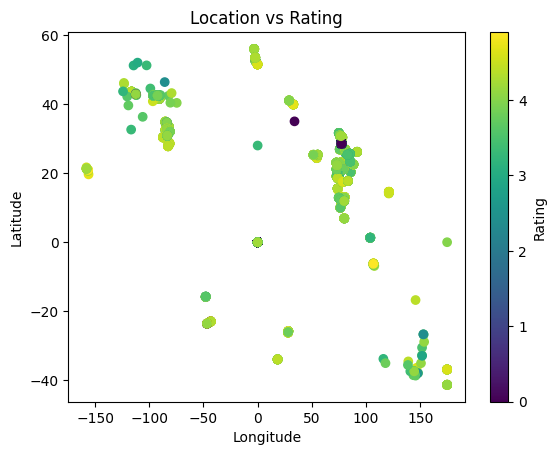

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(df['Longitude'], df['Latitude'], c=df['Aggregate rating'])
plt.colorbar(label='Rating')
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Location vs Rating")
plt.show()

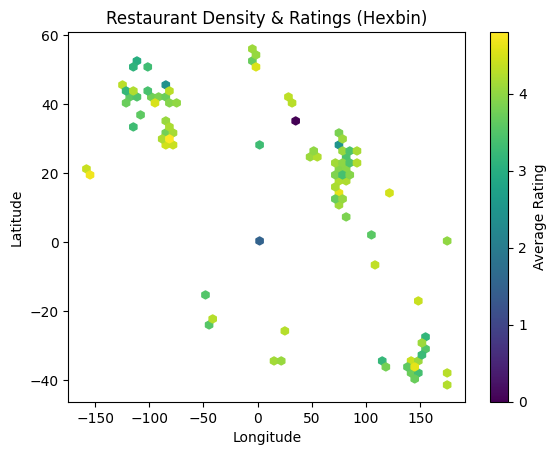

In [ ]:
#For better visualisation(Hexbin Plot)

plt.hexbin(df['Longitude'], df['Latitude'], C=df['Aggregate rating'],
           gridsize=50)
plt.colorbar(label='Average Rating')
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Restaurant Density & Ratings (Hexbin)")
plt.show()

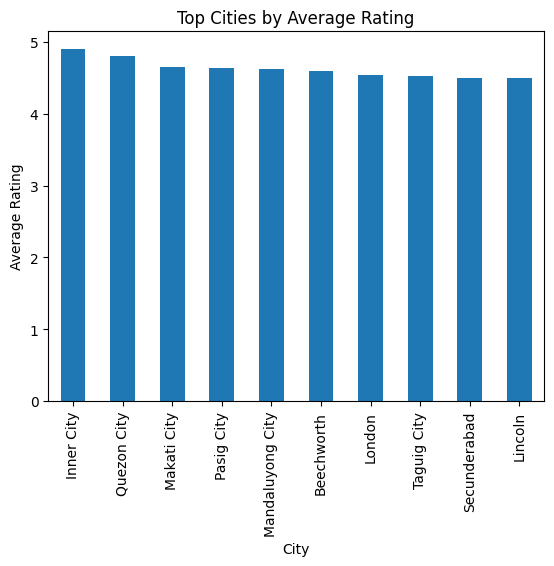

In [ ]:
#City wise Average Rating

city_rating = df.groupby('City')['Aggregate rating'].mean().sort_values(ascending=False).head(10)

city_rating.plot(kind='bar')
plt.title("Top Cities by Average Rating")
plt.xlabel("City")
plt.ylabel("Average Rating")
#plt.xticks(rotation=45)
plt.show()

In [24]:
#Visualisation using heatmap

import folium
from folium.plugins import HeatMap

map_center = [df['Latitude'].mean(), df['Longitude'].mean()]
heat_map = folium.Map(location=map_center, zoom_start=5)

HeatMap(df[['Latitude', 'Longitude']].dropna()).add_to(heat_map)

heat_map.save("heatmap.html")

from google.colab import files
files.download("heatmap.html")

heat_map


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [25]:
#coloring of markers by rating

for index, row in df.head(100).iterrows():
    color = 'red' if row['Aggregate rating'] >= 4 else 'red'

    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=5,
        color=color,
        fill=True
    ).add_to(restaurant_map)


restaurant_map.save("restaurant_map_rating.html")

from google.colab import files
files.download("restaurant_map_rating.html")
restaurant_map

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>